# SPERR

[![Citation]](https://doi.org/10.1109/ipdps54959.2023.00104)
[![Source]](https://github.com/NCAR/SPERR)

[Citation]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[Source]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white

SPERR [^sperr] (*SP*eck with *ERR*or bounding, pronounced *spur*) is a wavelet-based compression algorithm for 2D and 3D floating-point data that achieves high compression rates. It can bound the pointwise absolute compression error by correcting outliers and is tuned to minimise the combined cost of compression and corrections. SPERR produces a bitstream that can be truncated during decompression to reproduce the data with lower quality more quickly.

SPERR supports three compression modes: (1) targeting a specific compression ratio, (2) bounding the pointwise absolute error, or (3) bounding the peak signal-to-noise ratio. There is also an experimental mode for setting SPERR's internal quantisation step `q` directly.

[^sperr]: Li, S., Lindstrom, P., & Clyne, J. (2023). Lossy Scientific Data Compression With SPERR. *2023 IEEE International Parallel and Distributed Processing Symposium (IPDPS)*, 1007–1017. Available from: [doi:10.1109/ipdps54959.2023.00104](https://doi.org/10.1109/ipdps54959.2023.00104).

In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `Sperr` compressor

In [4]:
from numcodecs_wasm_sperr import Sperr

In [5]:
?Sperr

Init signature: Sperr(mode, _version='0.2.0', bpp=None, psnr=None, pwe=None, q=None)
Docstring:     
Codec providing compression using SPERR.

Arrays that are higher-dimensional than 3D are encoded by compressing each
3D slice with SPERR independently. Specifically, the array's shape is
interpreted as `[.., depth, height, width]`. If you want to compress 3D
slices along three different axes, you can swizzle the array axes
beforehand.

Parameters
----------
mode : ...
     - "bpp": Fixed bit-per-pixel rate
    
     - "psnr": Fixed peak signal-to-noise ratio
    
     - "pwe": Fixed point-wise (absolute) error
    
     - "q": Fixed quantisation step
_version : ..., optional, default = "0.2.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
bpp : ..., optional
    positive bits-per-pixel
psnr : ..., optional
    positive peak signal-to-noise ratio
pwe : ..., optional
    positive point-wise (absolute) error
q : ..., optional
    positive quantisation s

## Targeting a specific compression ratio

SPERR can target a specific compression ratio using:

In [6]:
cr = 10  # x10 compression

# dtype = da.dtype
dtype = np.dtype(np.float64)  # for example

Sperr(mode="bpp", bpp=dtype.itemsize * 8 / cr)

Sperr(mode='bpp', bpp=6.4, _version='0.2.0')

## Bounding the peak signal-to-noise ratio

SPERR can bound the PSNR using:

In [7]:
psnr = 50  # dB

Sperr(mode="psnr", psnr=psnr)

Sperr(mode='psnr', psnr=50.0, _version='0.2.0')

## Bounding the pointwise absolute error

SPERR can bound the absolute error using:

In [8]:
eb_abs = 0.1

Sperr(mode="pwe", pwe=eb_abs)

Sperr(mode='pwe', pwe=0.1, _version='0.2.0')

Note that SPERR can sometimes violate this pointwise absolute error bound[^lc][^climatebenchpress].

[^lc]: Fallin, A., & Burtscher, M. (2024). Lessons learned on the path to guaranteeing the error bound in lossy quantizers. *arXiv*. Available from: [doi:10.48550/arxiv.2407.15037](https://doi.org/10.48550/arxiv.2407.15037).

[^climatebenchpress]: Reichelt, T., Tyree, J., Klöwer, M., Dueben, P., Lawrence, B. N., Baker, A. H., Faghih-Naini, S., Hoefler, T., & Stier, P. (2026). ClimateBenchPress (v1.0): A Benchmark for Lossy Compression of Climate Data. *EGUsphere [Preprint]*. Available from: [doi:10.5194/egusphere-2026-60](https://doi.org/10.5194/egusphere-2026-60).

## Bounding the pointwise relative error

The easiest way to bound the pointwise relative error with SPERR is to transform the relative error bound into an absolute error bound [^pwrel] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^libpressio] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

[^pwrel]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

In [9]:
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1 + eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={**Sperr(mode="pwe", pwe=4.2).get_config(), "pwe": "$eb_abs"},
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)

PointwiseRatioErrorBoundedCodec(eb_ratio=1.01, eb_abs_marker='$eb_abs', log_codec={'id': 'sperr.rs', 'mode': 'pwe', 'pwe': '$eb_abs', '_version': '0.2.0'}, sign_codec=Zstd(level=3, _version='0.1.0'))

## Preserving NaN Missing Values

SPERR itself does not support preserving infinite and NaN values and raises an exception when compressing data that includes non-finite values. However, the HDF5 filter plugin for SPERR, H5Z-SPERR [^h5zsperr], which is included in the `hdf5plugin` Python package for `h5py`, supports preserving NaN missing values (mode 1) and missing values encoded as a sentinel with magnitude larger than `1e35`. Alternatively, a filter such as `numcodecs_replace.ReplaceFilterCodec` can be used to replace all non-finite values before compressing with SPERR, though this will not recreate these values during decompression:

[^h5zsperr]: <https://github.com/NCAR/H5Z-SPERR>

In [10]:
from numcodecs_combinators.stack import CodecStack
from numcodecs_replace import Replacement, ReplaceFilterCodec

eb_abs = 1.0

CodecStack(
    ReplaceFilterCodec(
        replacements={
            np.nan: "finite_mean",
            -np.inf: "finite_min",
            np.inf: "finite_max",
        }
    ),
    Sperr(mode="pwe", pwe=eb_abs),
)

CodecStack(ReplaceFilterCodec(replacements={nan: 'finite_mean', -inf: 'finite_min', inf: 'finite_max'}), Sperr(mode='pwe', pwe=1.0, _version='0.2.0'))

## Example

In [11]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [12]:
psnr = 50.0  # dB

codec = Sperr(mode="psnr", psnr=psnr)

In [13]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

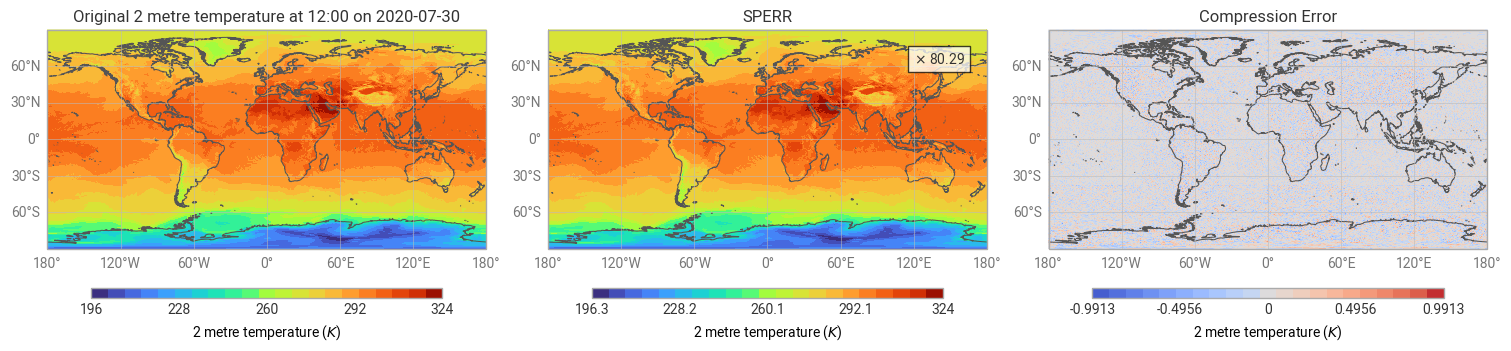

In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="SPERR", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()